<a href="https://colab.research.google.com/github/elidoeliazafy/Exam-Hackathon-ML/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Importation des bibliothèques et chargement`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Utilisation du lien 'raw' pour lire le CSV directement
url = "https://raw.githubusercontent.com/elidoeliazafy/Exam-Hackathon-ML/main/ressources/dataset.csv"
df = pd.read_csv(url)

print(f"Dimensions du dataset : {df.shape}")
df.head()

Dimensions du dataset : (2423, 20)


,c0_x,c0_o,c1_x,c1_o,c2_x,c2_o,c3_x,c3_o,c4_x,c4_o,c5_x,c5_o,c6_x,c6_o,c7_x,c7_o,c8_x,c8_o,x_wins,is_draw
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
3,1,0,0,1,1,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0
4,1,0,0,1,1,0,0,1,1,0,0,1,0,1,1,0,0,0,1,0


`Premier coup d'œil (Validation des contraintes)`

In [ ]:
# Vérification des types et des valeurs manquantes
print(df.info())

# Vérification rapide des statistiques
# (Moyenne proche de 0.5 = équilibré, proche de 0 ou 1 = déséquilibré)
print(df[['x_wins', 'is_draw']].mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2423 entries, 0 to 2422
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   c0_x     2423 non-null   int64
 1   c0_o     2423 non-null   int64
 2   c1_x     2423 non-null   int64
 3   c1_o     2423 non-null   int64
 4   c2_x     2423 non-null   int64
 5   c2_o     2423 non-null   int64
 6   c3_x     2423 non-null   int64
 7   c3_o     2423 non-null   int64
 8   c4_x     2423 non-null   int64
 9   c4_o     2423 non-null   int64
 10  c5_x     2423 non-null   int64
 11  c5_o     2423 non-null   int64
 12  c6_x     2423 non-null   int64
 13  c6_o     2423 non-null   int64
 14  c7_x     2423 non-null   int64
 15  c7_o     2423 non-null   int64
 16  c8_x     2423 non-null   int64
 17  c8_o     2423 non-null   int64
 18  x_wins   2423 non-null   int64
 19  is_draw  2423 non-null   int64
dtypes: int64(20)
memory usage: 378.7 KB
None
x_wins     0.787866
is_draw    0.172101
dtype: float64




---


## Étape 1 : Exploratory Data Analysis (EDA)


---



### 1.1 Visualisation du Déséquilibre

Pour qu'un dataset soit considéré comme "équilibré", on s'attendrait à ce que les barres de chaque graphique soient à peu près de la même hauteur (environ 50/50 pour de la classification binaire).

Par contre le graphe ci-dessous montre le clairement contraire avec :

    Cible A (x_wins) : Il y a presque 4 fois plus de "X ne gagne pas" que de "X gagne".

    Cible B (is_draw) : Il y a environ 5 fois plus de "Pas nul" que de "Match nul".

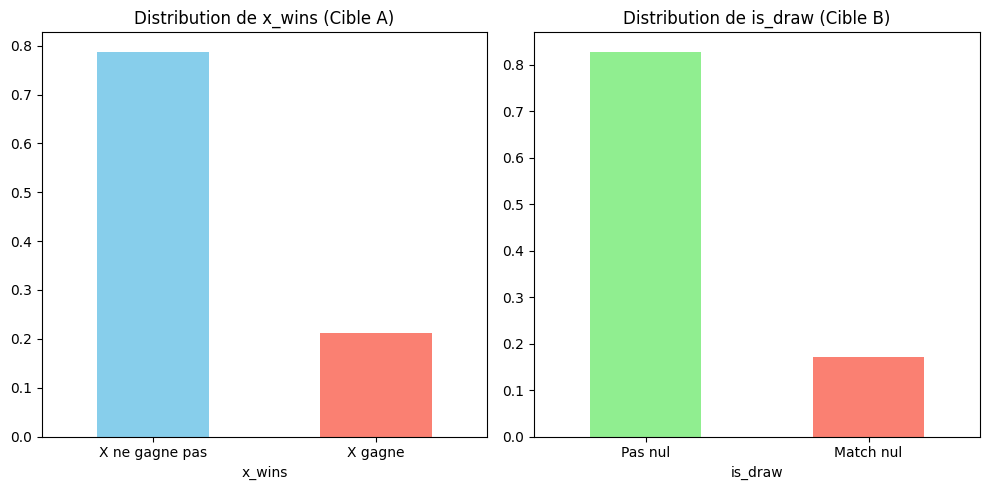

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['x_wins'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution de x_wins (Cible A)')
plt.xticks([0, 1], ['X ne gagne pas', 'X gagne'], rotation=0)

plt.subplot(1, 2, 2)
df['is_draw'].value_counts(normalize=True).plot(kind='bar', color=['lightgreen', 'salmon'])
plt.title('Distribution de is_draw (Cible B)')
plt.xticks([0, 1], ['Pas nul', 'Match nul'], rotation=0)

plt.tight_layout()
plt.show()

### 1.2 Analyse de la case stratégique (Le rôle de X)
Le graphe montre le nombre de fois où chaque case du plateau 3×3 est occupée par un "X" dans le dataset

* Case centrale (615) : C'est la valeur la plus élevée du plateau. Cela signifie que dans la grande majorité des scénarios de victoire, X occupe le centre.

* Les coins (559, 573, 593, 596) : Ils affichent des valeurs élevées, montrant que les coins sont la deuxième priorité stratégique après le centre.

* Les milieux de bord (536, 545, 550, 568) : Ce sont les cases les moins occupées lors des victoires

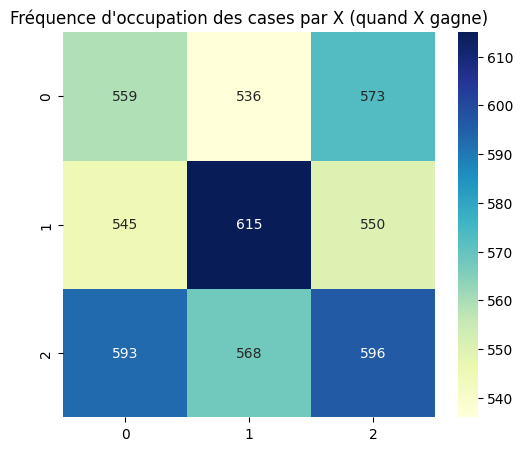

In [ ]:
# On filtre les états où X gagne
df_wins = df[df['x_wins'] == 1]

# On somme les colonnes ci_x pour voir la fréquence d'occupation
x_occupations = [df_wins[f'c{i}_x'].sum() for i in range(9)]

# On remet sous forme de grille 3x3
grid_occupations = np.array(x_occupations).reshape(3, 3)

plt.figure(figsize=(6, 5))
sns.heatmap(grid_occupations, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Fréquence d'occupation des cases par X (quand X gagne)")
plt.show()

### 1.3 Heatmap de Corrélation

Pour identifier les relations entre les positions et les cibles.

On observe la ligne c4_o (le pion 'O' au centre) :

    Corrélation avec x_wins (-0.26) : C'est la valeur la plus forte du graphique. Elle est négative, ce qui signifie que si 'O' occupe le centre, les chances que 'X' gagne chutent drastiquement.

    Corrélation avec is_draw (0.24) : C'est très élevé. Si 'O' prend le centre, la probabilité d'un match nul augmente fortement.

Interprétation stratégique : Ce dataset capture parfaitement la règle d'or du Morpion : le centre est la case la plus importante pour empêcher l'adversaire de gagner.

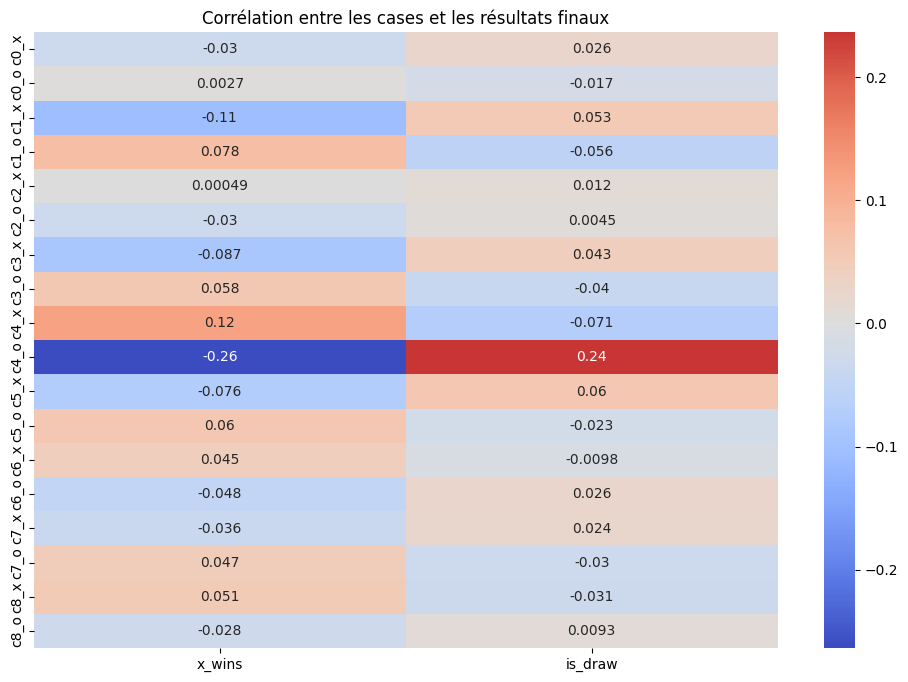

In [ ]:
plt.figure(figsize=(12, 8))
# On corrèle toutes les features avec les deux cibles uniquement
corr = df.corr()[['x_wins', 'is_draw']].drop(['x_wins', 'is_draw'])
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Corrélation entre les cases et les résultats finaux")
plt.show()



---


## Étape 2 : La Baseline


---



### 2.1 Préparation et Entraînement

Nous allons d'abord séparer les données en caractéristiques (X) et cibles (y), puis diviser le tout en ensembles d'entraînement et de test.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Séparation des features (18 colonnes) et des cibles
X = df.drop(columns=['x_wins', 'is_draw'])
y_wins = df['x_wins']
y_draw = df['is_draw']

# Split pour x_wins
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X, y_wins, test_size=0.2, random_state=42)

# Split pour is_draw
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X, y_draw, test_size=0.2, random_state=42)

# Entraînement des deux modèles
model_wins = LogisticRegression()
model_wins.fit(X_train_w, y_train_w)

model_draw = LogisticRegression()
model_draw.fit(X_train_d, y_train_d)

LogisticRegression()

### 2.2 Évaluation des Performances

Les deux modèles baseline souffrent d'un phénomène de convergence vers la classe majoritaire. Bien que les scores d'Accuracy paraissent élevés (80.6% pour x_wins et 84.7% pour is_draw), ils ne reflètent aucune capacité prédictive réelle. En effet, ces scores sont quasiment identiques à la distribution statistique des classes dans le dataset d'origine (le Zero-Rule Baseline).

Modèle x_wins (Biais Partiel)

Pour la prédiction des victoires de X, le modèle est partiellement dégénéré :

    Recall asymétrique : Le modèle identifie presque toutes les victoires (0.97), mais il est incapable de détecter les cas où X ne gagne pas (0.09).

    Sur-prédiction : La matrice de confusion montre un volume critique de Faux Positifs (83 cas). Le modèle 'parie' massivement sur la victoire de X pour maximiser son score global, ignorant les subtilités tactiques du plateau.

Modèle is_draw (Dégénérescence Totale)

Le modèle de match nul est un classifieur naïf (constant) :

    Recall nul : Le score de 0.00 sur la classe 1 démontre que le modèle n'a appris aucun pattern associé au match nul.

    Effondrement du modèle : Face à la difficulté de corrélation linéaire (vue en heatmap) et au déséquilibre (85/15), l'algorithme a choisi de ne prédire que la classe 0.

    Conclusion technique : Le modèle n'apporte aucune plus-value informative par rapport à un choix aléatoire basé sur la fréquence.

--- Modèle x_wins ---
Accuracy: 0.8062

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.09      0.15        91
           1       0.82      0.97      0.89       394

    accuracy                           0.81       485
   macro avg       0.62      0.53      0.52       485
weighted avg       0.75      0.81      0.75       485



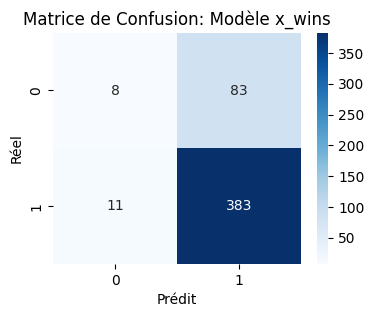

--- Modèle is_draw ---
Accuracy: 0.8474

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       411
           1       0.00      0.00      0.00        74

    accuracy                           0.85       485
   macro avg       0.42      0.50      0.46       485
weighted avg       0.72      0.85      0.78       485



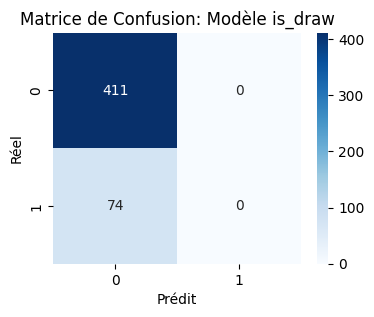

In [ ]:
def evaluate(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    print(f"--- {title} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matrice de Confusion: {title}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

evaluate(model_wins, X_test_w, y_test_w, "Modèle x_wins")
evaluate(model_draw, X_test_d, y_test_d, "Modèle is_draw")

### 2.3 Analyse des Coefficients (Obligatoire)

**Analyse de la Victoire de X (Ligne du haut)**

Le modèle a appris des règles de survie plutôt que des règles de victoire :

  * La stratégie de défense (Influence de O) : On remarque le carré bleu foncé à -1.2 au centre. C'est le coefficient le plus fort. Le modèle dit : "Si O est au centre, il est presque impossible que X gagne". C'est un pattern spatial très fort.

  * Le biais de X : Pour "Victoire X", beaucoup de cases occupées par X (en haut à gauche) ont des coefficients négatifs (bleu). Cela signifie que dans le dataset, la présence de X dans ces cases est statistiquement corrélée à une non-victoire.

**Analyse du Match Nul (Ligne du bas)**

C'est ici que l'on observe pourquoi le modèle ne prédisait jamais de nul :

  * L'influence de O au centre (1.3) : Le modèle a identifié que si O prend le centre, la probabilité d'un match nul explose (couleur rouge foncé).

  * L'influence de X : Presque tout le plateau pour X est "orange/rouge". Le modèle pense que presque n'importe quel coup de X favorise un nul.
    

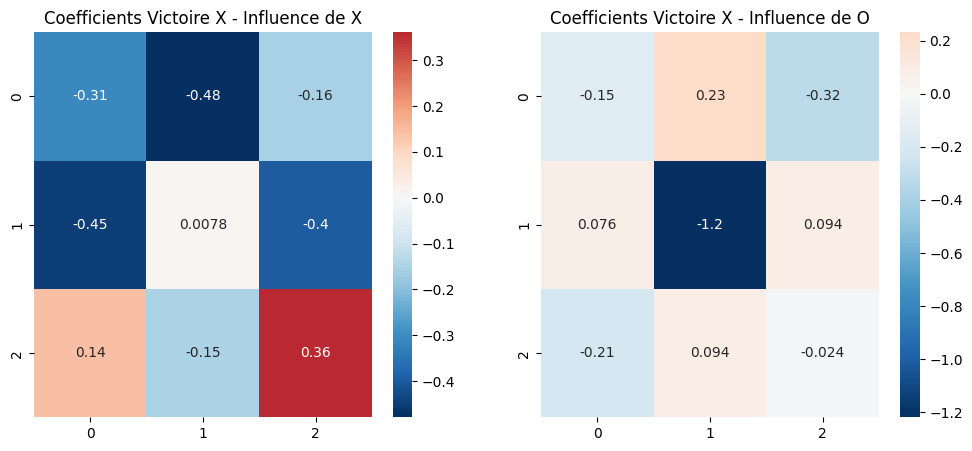

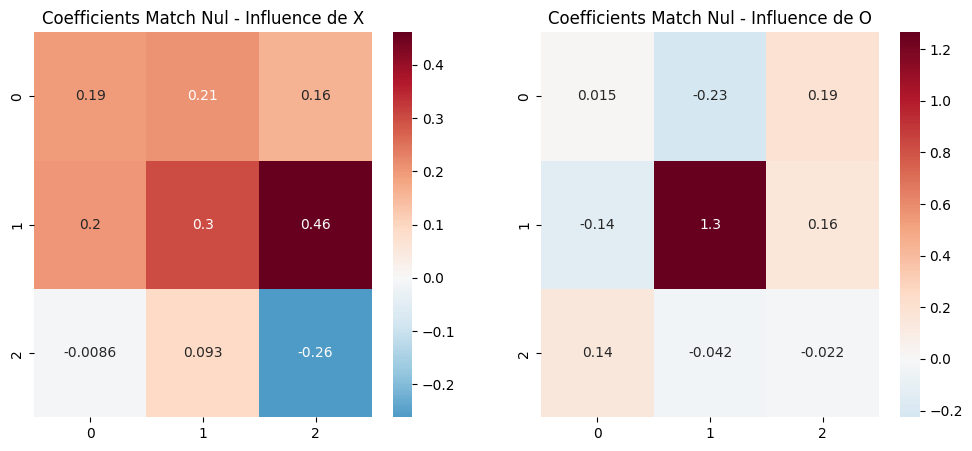

In [ ]:
def plot_coefficients(model, title):
    coefs = model.coef_[0]
    # Séparation des coefficients pour X et pour O
    coefs_x = coefs[0::2] # Indices pairs : c0_x, c1_x...
    coefs_o = coefs[1::2] # Indices impairs : c0_o, c1_o...

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(coefs_x.reshape(3,3), annot=True, cmap='RdBu_r', center=0)
    plt.title(f"{title} - Influence de X")

    plt.subplot(1, 2, 2)
    sns.heatmap(coefs_o.reshape(3,3), annot=True, cmap='RdBu_r', center=0)
    plt.title(f"{title} - Influence de O")

    plt.show()

plot_coefficients(model_wins, "Coefficients Victoire X")
plot_coefficients(model_draw, "Coefficients Match Nul")

### Le verdict : Lequel est le plus difficile ?

Le modèle **is_draw** (Match nul) est nettement plus difficile à apprendre que le modèle x_wins.

Dans les faits, le modèle is_draw a totalement échoué (Recall de 0), tandis que le modèle x_wins a au moins réussi à capturer une partie du signal (Recall de 0.09 et Precision de 0.42 sur la classe minoritaire).

Il existe trois raisons techniques et mathématiques à cette difficulté :

A. La nature de l'alignement (Signal Linéaire vs Non-Linéaire)

    Pour x_wins : Il suffit souvent que quelques cases clés soient occupées par 'X' (comme le centre ou les coins) pour augmenter statistiquement les chances de victoire. Il y a un signal linéaire partiel.

    Pour is_draw : Un match nul est le résultat d'une absence d'alignement sur l'ensemble des 8 lignes possibles après 9 coups. C'est une condition "globale" et non locale. Un seul pion adverse placé au mauvais endroit casse la structure. Pour un modèle linéaire, cette "négativité combinatoire" est un cauchemar mathématique.

B. La rareté statistique (Déséquilibre extrême)

    Notre premier graphique montrait que les matchs nuls sont la classe la plus rare (~17%).Le modèle choisit alors la solution de facilité : l'ignorer totalement pour minimiser sa fonction de perte.

C. L'entropie de la configuration

    Il y a beaucoup plus de configurations de plateaux menant à un match nul qui ressemblent à des victoires ratées.

    Comme on l'a vu sur nos Heatmaps de coefficients, le modèle "hésite" : il donne des poids forts au centre pour le nul, mais ces mêmes poids parasitent la détection des victoires.



---




## Étape 3 : Modèles Avancés


---



### 3.1 Analyse des Modèles Avancés
L'analyse de la Baseline (Régression Logistique) a montré des limites significatives, notamment une incapacité à prédire la classe minoritaire des matchs nuls (is_draw) et une difficulté à capturer les interactions non-linéaires entre les cases du plateau.

Pour améliorer ces performances, nous explorons ici des modèles plus puissants basés sur les ensembles d'arbres de décision:

* Random Forest : Ce modèle utilise le "bagging" pour réduire la variance et améliorer la robustesse. Nous utilisons l'hyperparamètre class_weight='balanced' pour forcer le modèle à accorder plus d'importance aux classes sous-représentées (comme les matchs nuls).

* XGBoost (Extreme Gradient Boosting) : Un algorithme de "boosting" reconnu pour sa grande efficacité sur les données tabulaires. Il construit des arbres de manière séquentielle pour corriger les erreurs des précédents, ce qui est idéal pour apprendre des configurations de jeu complexes.

L'objectif de cette étape est de comparer ces modèles sur nos deux cibles (x_wins et is_draw) en utilisant le F1-Score comme métrique principale de décision.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier # Si non installé : !pip install xgboost

def train_advanced_models(X_train, y_train, X_test, y_test, target_name):
    print(f"\n===== Entraînement Modèles Avancés pour : {target_name} =====")

    # 1. Random Forest (Gère mieux le déséquilibre avec 'balanced')
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    print(f"\n[Random Forest] Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
    print(classification_report(y_test, y_pred_rf))

    # 2. XGBoost
    xgb = XGBClassifier(eval_metric='logloss', random_state=42)
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    print(f"\n[XGBoost] Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
    print(classification_report(y_test, y_pred_xgb))

    return rf, xgb

# Application sur les deux cibles
rf_w, xgb_w = train_advanced_models(X_train_w, y_train_w, X_test_w, y_test_w, "x_wins")
rf_d, xgb_d = train_advanced_models(X_train_d, y_train_d, X_test_d, y_test_d, "is_draw")


===== Entraînement Modèles Avancés pour : x_wins =====

[Random Forest] Accuracy: 0.8969
              precision    recall  f1-score   support

           0       0.87      0.53      0.66        91
           1       0.90      0.98      0.94       394

    accuracy                           0.90       485
   macro avg       0.89      0.75      0.80       485
weighted avg       0.89      0.90      0.89       485


[XGBoost] Accuracy: 0.9381
              precision    recall  f1-score   support

           0       0.88      0.78      0.83        91
           1       0.95      0.97      0.96       394

    accuracy                           0.94       485
   macro avg       0.91      0.88      0.89       485
weighted avg       0.94      0.94      0.94       485


===== Entraînement Modèles Avancés pour : is_draw =====

[Random Forest] Accuracy: 0.9072
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       411
           1       0.89     

### 3.2 Comparaison : Baseline vs Modèles Avancés

Le passage de modèles linéaires à des modèles basés sur des ensembles d'arbres a radicalement transformé les performances de notre IA. Voici l'analyse comparative :

1. Cible x_wins (Victoire de X)

  * Baseline : Avait une Accuracy de 0.8062 mais un F1-score très faible pour la classe 0 (0.15). Le modèle peinait à identifier quand X ne gagnait pas.

  * XGBoost (Grand gagnant) : Atteint une Accuracy de 0.9381 et un F1-score de 0.96 pour la victoire. Plus important encore, il détecte les non-victoires avec un F1-score de 0.83 (contre 0.15 auparavant).

2. Cible is_draw (Match Nul) - La plus grande amélioration

C'est ici que la différence est la plus spectaculaire :

  * Baseline : Affichait 0.00 de rappel et de F1-score pour les matchs nuls. Elle était totalement incapable de prédire un nul.

  * XGBoost : Récupère un F1-score de 0.77 avec un rappel de 0.73. L'IA est désormais capable de détecter les situations de blocage dans 73% des cas.

  * Random Forest : Bien que performant sur l'accuracy globale, il reste moins efficace que XGBoost sur le rappel des nuls (0.45 contre 0.73).


#4. Exportation des Modèles

Nous allons exporter les modèles entraînés en utilisant `joblib`. Cela permettra de les sauvegarder et de les réutiliser ultérieurement sans avoir à les ré-entraîner.

In [20]:
import joblib
from google.colab import files

# 1. Sauvegarde locale dans l'environnement Colab
joblib.dump(xgb_w, 'model_x_wins.pkl')
joblib.dump(xgb_d, 'model_is_draw.pkl')

print("Fichiers sauvegardés localement. Lancement du téléchargement...")

# 2. Téléchargement sur votre ordinateur
files.download('model_x_wins.pkl')
files.download('model_is_draw.pkl')

Fichiers sauvegardés localement. Lancement du téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>